# Phân tích cảm xúc văn bản tài chính và ứng dụng trên báo cáo thường niên của doanh nghiệp

**Financial Text Sentiment Analysis and Its Application to Corporate Annual Reports**

Notebook này là **file code chính duy nhất** của bài cuối học phần NLP. Có thể chạy trên Google Colab hoặc Visual Studio Code bằng cách chọn **Restart Kernel and Run All**.

## Phân công công việc

| Thành viên | MSSV | Tỷ trọng | Phần công việc chính |
|---|---|---:|---|
| Nguyễn Tùng Dương | [24100358] | 33% | Thu thập dữ liệu, kiểm tra nhãn, tiền xử lý, EDA, chia dữ liệu, xây dựng phần phương pháp và tích hợp báo cáo |
| Phạm Thế Duy | [24100583] | 33% | Xây dựng baseline, huấn luyện, lựa chọn mô hình, đánh giá test, confusion matrix và phân tích lỗi |
| Ngô Quang Thiện | [24102651] | 33% | Thiết kế ứng dụng PDF, tổng hợp trực quan, xây dựng slide, chuẩn bị bảo vệ và kiểm tra bản cuối |


## 1. Mục tiêu và quy trình

Bài toán là phân loại cảm xúc của câu tài chính tiếng Anh thành ba lớp: **negative**, **neutral** và **positive**. Dữ liệu huấn luyện chính là Financial PhraseBank cấu hình `sentences_75agree`. Sau khi huấn luyện và đánh giá, mô hình tốt nhất được dùng để minh họa phân tích các câu trích xuất từ một báo cáo thường niên PDF.

Quy trình thực hiện gồm 8 bước:
1. Tải dữ liệu Financial PhraseBank.
2. Kiểm tra chất lượng và tiền xử lý văn bản.
3. Phân tích khám phá dữ liệu (EDA).
4. Chia dữ liệu thành train / validation / test.
5. Huấn luyện và tinh chỉnh 4 mô hình baseline trên tập train.
6. Chọn mô hình tốt nhất dựa trên tập validation.
7. Đánh giá mô hình đã chọn trên tập test (chỉ một lần duy nhất).
8. Phân tích lỗi chi tiết và áp dụng mô hình lên một báo cáo PDF thật.

## 2. Cài đặt và import thư viện

Cell này cài đặt các thư viện cần thiết khi chạy trên Google Colab: xử lý dữ liệu (`pandas`, `numpy`), trực quan hóa (`matplotlib`), học máy (`scikit-learn`) và đọc file PDF (`pymupdf`, `pdfplumber`). Khi chạy bằng Visual Studio Code, nên cài trước bằng `pip install -r requirements.txt`.

In [1]:
import sys, subprocess, importlib.util, platform
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %pip install -q pandas numpy matplotlib scikit-learn pymupdf pdfplumber

import os, re, time, random, unicodedata, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

print('Phiên bản Python:', platform.python_version())
print('Phiên bản pandas:', pd.__version__)
import sklearn
print('Phiên bản scikit-learn:', sklearn.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 39.5 MB/s eta 0:00:00
Phiên bản Python: 3.12.13
Phiên bản pandas: 2.2.2
Phiên bản scikit-learn: 1.6.1


## 3. Cấu hình chung

Chỉ cần sửa các biến trong cell này để bật/tắt từng bước của notebook (ví dụ khi muốn chạy lại nhanh một phần mà không chạy lại toàn bộ).

In [2]:
import random
from pathlib import Path

import numpy as np

SEED = 42

RUN_DATA_COLLECTION = True
RUN_EDA = True
RUN_BASELINE_MODELS = True
RUN_REPORT_INFERENCE = True

REPORT_PDF_PATH = None  # Dùng trong VS Code, ví dụ: r'C:/Users/.../report.pdf'

random.seed(SEED)
np.random.seed(SEED)

FIGURES = Path('figures_from_notebook')
FIGURES.mkdir(exist_ok=True)

STAGE_STATUS = {}
print('Cấu hình đã sẵn sàng.')

Cấu hình đã sẵn sàng.


## 4. Thu thập dữ liệu Financial PhraseBank

Dữ liệu sử dụng là Financial PhraseBank cấu hình `sentences_75agree`, gồm các câu có mức đồng thuận nhãn từ 75% trở lên. Do các phiên bản mới của `datasets` không còn hỗ trợ dataset script cũ, notebook tải trực tiếp file ZIP gốc công khai trên Hugging Face, đọc `Sentences_75Agree.txt` và chuẩn hóa nhãn về ba lớp: **negative**, **neutral** và **positive**. Cách này không yêu cầu `HF_TOKEN` và không phụ thuộc vào file Parquet chưa có trên nhánh `main`.


In [3]:
raw_df = None

from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError
import shutil
import zipfile

DATASET_ZIP_URL = (
    "https://huggingface.co/datasets/takala/financial_phrasebank/"
    "resolve/main/data/FinancialPhraseBank-v1.0.zip"
)
DATASET_ZIP_PATH = Path("data/FinancialPhraseBank-v1.0.zip")
DATASET_MEMBER_SUFFIX = "Sentences_75Agree.txt"
EXPECTED_SAMPLE_COUNT = 3453

LABEL_ORDER = ["negative", "neutral", "positive"]
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {label_id: label for label, label_id in LABEL2ID.items()}


def download_file(url: str, destination: Path, timeout: int = 120) -> Path:
    """
    Tải file bằng HTTP công khai.

    Không dùng Hugging Face API nên không cần HF_TOKEN và không xuất hiện
    cảnh báo yêu cầu xác thực. File đã tải được giữ lại để dùng cho lần chạy sau.
    """
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    # Dùng lại cache nếu file ZIP đã tồn tại và đọc được.
    if destination.exists():
        try:
            with zipfile.ZipFile(destination, "r") as archive:
                if archive.testzip() is None:
                    print("Dùng lại file dữ liệu đã tải:", destination)
                    return destination
        except zipfile.BadZipFile:
            print("File cache không hợp lệ, tiến hành tải lại.")
            destination.unlink(missing_ok=True)

    temporary_path = destination.with_suffix(destination.suffix + ".part")
    temporary_path.unlink(missing_ok=True)

    request = Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0",
            "Accept": "application/zip,application/octet-stream,*/*",
        },
    )

    try:
        with urlopen(request, timeout=timeout) as response:
            with temporary_path.open("wb") as output_file:
                shutil.copyfileobj(response, output_file)
    except HTTPError as exc:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError(
            f"Hugging Face trả về HTTP {exc.code}: {exc.reason}"
        ) from exc
    except URLError as exc:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError(
            f"Không thể kết nối tới Hugging Face: {exc.reason}"
        ) from exc
    except Exception:
        temporary_path.unlink(missing_ok=True)
        raise

    if not temporary_path.exists() or temporary_path.stat().st_size == 0:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError("File tải về rỗng.")

    try:
        with zipfile.ZipFile(temporary_path, "r") as archive:
            bad_member = archive.testzip()
            if bad_member is not None:
                raise RuntimeError(
                    f"File ZIP bị lỗi tại thành phần: {bad_member}"
                )
    except zipfile.BadZipFile as exc:
        temporary_path.unlink(missing_ok=True)
        raise RuntimeError(
            "Nội dung tải về không phải file ZIP hợp lệ."
        ) from exc

    temporary_path.replace(destination)
    print("Đã tải dữ liệu về:", destination)
    return destination


def read_financial_phrasebank_zip(zip_path: Path) -> pd.DataFrame:
    """
    Đọc Sentences_75Agree.txt trong file ZIP chính thức.

    Định dạng mỗi dòng:
        sentence@label

    Dùng rsplit('@', 1) để không làm hỏng câu nếu trong nội dung có ký tự @.
    """
    records = []

    with zipfile.ZipFile(zip_path, "r") as archive:
        matching_members = [
            name
            for name in archive.namelist()
            if name.endswith(DATASET_MEMBER_SUFFIX)
        ]

        if len(matching_members) != 1:
            raise FileNotFoundError(
                "Không tìm thấy duy nhất file "
                f"`{DATASET_MEMBER_SUFFIX}` trong ZIP. "
                f"Các file tìm được: {matching_members}"
            )

        member_name = matching_members[0]

        with archive.open(member_name, "r") as source_file:
            for line_number, raw_line in enumerate(source_file, start=1):
                line = raw_line.decode("iso-8859-1").strip()

                if not line:
                    continue

                if "@" not in line:
                    raise ValueError(
                        f"Dòng {line_number} không có dấu phân cách nhãn '@'."
                    )

                sentence, label = line.rsplit("@", 1)
                sentence = sentence.strip()
                label = label.strip().lower()

                if not sentence:
                    raise ValueError(
                        f"Dòng {line_number} có nội dung câu rỗng."
                    )

                if label not in LABEL2ID:
                    raise ValueError(
                        f"Dòng {line_number} có nhãn không hợp lệ: {label!r}"
                    )

                records.append(
                    {
                        "sentence": sentence,
                        "label": label,
                        "label_id": LABEL2ID[label],
                    }
                )

    frame = pd.DataFrame.from_records(
        records,
        columns=["sentence", "label", "label_id"],
    )

    if frame.empty:
        raise ValueError("Không đọc được mẫu dữ liệu nào từ file ZIP.")

    frame["sentence"] = frame["sentence"].astype("string").str.strip()
    frame["label"] = frame["label"].astype("string").str.strip().str.lower()
    frame["label_id"] = frame["label_id"].astype("int64")

    invalid_labels = sorted(set(frame["label"]) - set(LABEL_ORDER))
    if invalid_labels:
        raise ValueError(f"Phát hiện nhãn không hợp lệ: {invalid_labels}")

    missing_labels = [
        label for label in LABEL_ORDER
        if label not in set(frame["label"])
    ]
    if missing_labels:
        raise ValueError(
            "Dataset thiếu nhãn mong đợi: " + ", ".join(missing_labels)
        )

    if len(frame) != EXPECTED_SAMPLE_COUNT:
        print(
            "Cảnh báo: số mẫu đọc được là",
            len(frame),
            "thay vì",
            EXPECTED_SAMPLE_COUNT,
            "như metadata hiện tại.",
        )

    return frame.reset_index(drop=True)


def load_financial_phrasebank() -> tuple[pd.DataFrame, str]:
    zip_path = download_file(DATASET_ZIP_URL, DATASET_ZIP_PATH)
    frame = read_financial_phrasebank_zip(zip_path)
    return frame, f"ZIP chính thức: {zip_path}"


if RUN_DATA_COLLECTION:
    try:
        raw_df, data_source = load_financial_phrasebank()

        STAGE_STATUS["data"] = "done"
        STAGE_STATUS["data_source"] = data_source

        print("Nguồn dữ liệu:", data_source)
        print("Số mẫu hợp lệ:", len(raw_df))
        print("Các cột:", raw_df.columns.tolist())

        display(raw_df.head())
        display(
            raw_df["label"]
            .value_counts()
            .reindex(LABEL_ORDER, fill_value=0)
            .rename_axis("label")
            .reset_index(name="count")
        )

    except Exception as exc:
        raw_df = None
        STAGE_STATUS["data"] = f"failed: {type(exc).__name__}"

        print("Không tải hoặc đọc được dataset.")
        print("Loại lỗi:", type(exc).__name__)
        print("Chi tiết:", str(exc))
        print(
            "Hãy kiểm tra kết nối Internet. Nếu file đã được tải thủ công, "
            "hãy đặt nó tại `data/FinancialPhraseBank-v1.0.zip` rồi chạy lại cell."
        )
        print(
            "Các bước sau sẽ tự động bỏ qua vì raw_df=None, "
            "thay vì phát sinh lỗi dây chuyền."
        )
else:
    STAGE_STATUS["data"] = "skipped_by_config"
    print("Bỏ qua tải dữ liệu theo cấu hình.")

Đã tải dữ liệu về: data/FinancialPhraseBank-v1.0.zip
Nguồn dữ liệu: ZIP chính thức: data/FinancialPhraseBank-v1.0.zip
Số mẫu hợp lệ: 3453
Các cột: ['sentence', 'label', 'label_id']


,sentence,label,label_id
0,"According to Gran , the company has no plans t...",neutral,1
1,With the new production plant the company woul...,positive,2
2,"For the last quarter of 2010 , Componenta 's n...",positive,2
3,"In the third quarter of 2010 , net sales incre...",positive,2
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,2


,label,count
0,negative,420
1,neutral,2146
2,positive,887


## 5. Kiểm tra và tiền xử lý dữ liệu

Với TF-IDF, văn bản được chuẩn hóa nhẹ: Unicode, khoảng trắng, lowercase và giữ lại số, phần trăm, ký hiệu tiền tệ, từ phủ định. Với FinBERT, vẫn ưu tiên dùng câu gốc hoặc câu chỉ được làm sạch tối thiểu.

In [4]:
NEGATION_WORDS = {'no','not','never','without','none','neither','nor','hardly','barely','scarcely','nothing','nobody','nowhere'}

def normalize_text(text: str) -> str:
    text = '' if text is None else str(text)
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def clean_for_tfidf(text: str) -> str:
    text = normalize_text(text).lower()
    text = re.sub(r'[^a-z0-9%$€£.,+\-() ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def add_text_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['sentence_original'] = out['sentence']
    out['sentence_clean'] = out['sentence'].map(clean_for_tfidf)
    out['word_count'] = out['sentence_original'].map(lambda s: len(str(s).split()))
    out['char_count'] = out['sentence_original'].map(lambda s: len(str(s)))
    out['has_number'] = out['sentence_original'].str.contains(r'\d', regex=True, na=False)
    out['has_percent'] = out['sentence_original'].str.contains(r'\d\s*%', regex=True, na=False)
    out['has_currency'] = out['sentence_original'].str.contains(r'[$€£]', regex=True, na=False)
    neg_pattern = r'\b(' + '|'.join(sorted(NEGATION_WORDS)) + r')\b'
    out['has_negation'] = out['sentence_original'].str.contains(neg_pattern, case=False, regex=True, na=False)
    return out

if raw_df is not None:
    df = add_text_features(raw_df)
    print('Số câu rỗng:', int((df['sentence_original'].str.strip() == '').sum()))
    print('Số nhãn thiếu:', int(df['label'].isna().sum()))
    print('Số câu trùng sau chuẩn hóa:', int(df.duplicated('sentence_clean').sum()))
    display(df[['sentence_original','sentence_clean','label','word_count','has_number','has_percent','has_negation']].head())
else:
    df = None
    print('Chưa có dữ liệu nên bỏ qua bước tiền xử lý.')

Số câu rỗng: 0
Số nhãn thiếu: 0
Số câu trùng sau chuẩn hóa: 5


,sentence_original,sentence_clean,label,word_count,has_number,has_percent,has_negation
0,"According to Gran , the company has no plans t...","according to gran , the company has no plans t...",neutral,25,False,False,True
1,With the new production plant the company woul...,with the new production plant the company woul...,positive,33,False,False,False
2,"For the last quarter of 2010 , Componenta 's n...","for the last quarter of 2010 , componenta s ne...",positive,39,True,False,False
3,"In the third quarter of 2010 , net sales incre...","in the third quarter of 2010 , net sales incre...",positive,29,True,True,False
4,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose to eur 13.1 mn from eur ...,positive,24,True,True,False


## 6. Phân tích dữ liệu khám phá (EDA)

Phần này giúp hiểu phân bố nhãn và đặc điểm câu tài chính trước khi huấn luyện mô hình.

,count,ratio
label,,
negative,420,0.1216
neutral,2146,0.6215
positive,887,0.2569


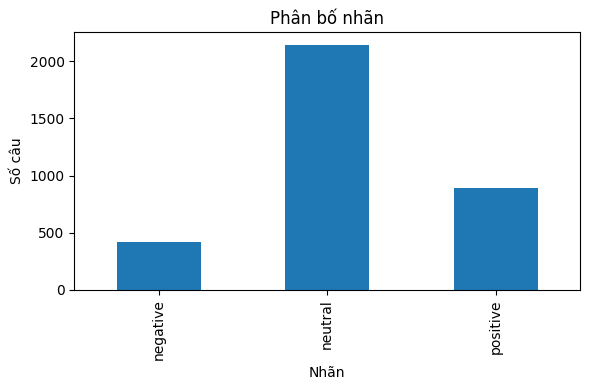

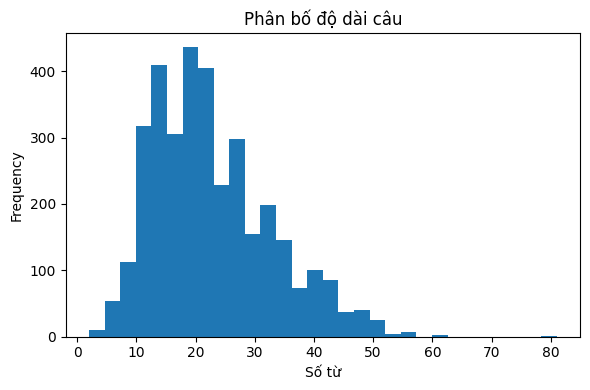

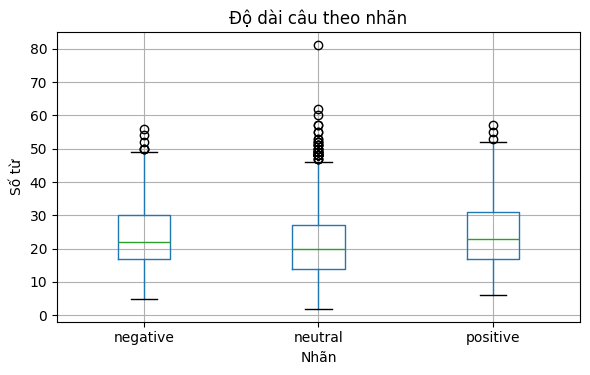

,has_number_ratio,has_percent_ratio,has_currency_ratio,has_negation_ratio
0,0.5772,0.0788,0.0394,0.04



N-gram phổ biến của lớp negative:


,ngram,count
2,eur,298
7,mn,213
11,profit,149
8,net,98
3,eur mn,96
14,year,87
9,operating,86
13,sales,85
12,quarter,83
0,2008,76



N-gram phổ biến của lớp neutral:


,ngram,count
3,company,382
4,eur,199
5,finland,161
8,million,154
7,group,145
10,said,142
2,business,141
14,shares,140
11,sales,131
9,new,124



N-gram phổ biến của lớp positive:


,ngram,count
1,eur,420
5,mn,239
14,year,194
6,net,186
10,profit,185
13,sales,161
12,said,156
2,finnish,152
3,million,143
0,company,140


In [5]:
eda_summary = None
if RUN_EDA and df is not None:
    label_counts = df['label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
    label_ratio = (label_counts / label_counts.sum()).round(4)
    eda_summary = pd.DataFrame({'count': label_counts, 'ratio': label_ratio})
    display(eda_summary)

    ax = label_counts.plot(kind='bar', figsize=(6,4), title='Phân bố nhãn')
    ax.set_xlabel('Nhãn')
    ax.set_ylabel('Số câu')
    plt.tight_layout()
    plt.savefig(FIGURES/'label_distribution.png', dpi=160)
    plt.show()

    ax = df['word_count'].plot(kind='hist', bins=30, figsize=(6,4), title='Phân bố độ dài câu')
    ax.set_xlabel('Số từ')
    plt.tight_layout()
    plt.savefig(FIGURES/'sentence_length_histogram.png', dpi=160)
    plt.show()

    df.boxplot(column='word_count', by='label', figsize=(6,4))
    plt.title('Độ dài câu theo nhãn')
    plt.suptitle('')
    plt.xlabel('Nhãn')
    plt.ylabel('Số từ')
    plt.tight_layout()
    plt.savefig(FIGURES/'sentence_length_by_label.png', dpi=160)
    plt.show()

    feat_table = pd.DataFrame({
        'has_number_ratio': [df['has_number'].mean()],
        'has_percent_ratio': [df['has_percent'].mean()],
        'has_currency_ratio': [df['has_currency'].mean()],
        'has_negation_ratio': [df['has_negation'].mean()],
    }).round(4)
    display(feat_table)

    for label in LABEL_ORDER:
        sample = df.loc[df['label']==label, 'sentence_clean']
        if len(sample) == 0: continue
        vec = CountVectorizer(ngram_range=(1,2), stop_words='english', max_features=15)
        mat = vec.fit_transform(sample)
        counts = np.asarray(mat.sum(axis=0)).ravel()
        ngrams = pd.DataFrame({'ngram': vec.get_feature_names_out(), 'count': counts}).sort_values('count', ascending=False).head(10)
        print(f'\nN-gram phổ biến của lớp {label}:')
        display(ngrams)
else:
    print('Chưa có dữ liệu hoặc RUN_EDA=False nên bỏ qua EDA.')

## 7. Chia train, validation và test

Dữ liệu được loại trùng trước khi chia để giảm nguy cơ data leakage. Tỷ lệ chia là 70% train, 15% validation và 15% test, stratified theo nhãn.

In [6]:
train_df = val_df = test_df = None

if df is not None:
    # Loai cau trung truoc khi chia, tranh viec 1 cau xuat hien o ca train va test
    data = df.drop_duplicates('sentence_clean').reset_index(drop=True).copy()

    # Chia 70% train, 15% validation, 15% test, giu nguyen ty le nhan (stratify)
    temp_train, temp_test = train_test_split(
        data, test_size=0.15, random_state=SEED, stratify=data['label']
    )
    relative_val = 0.15 / 0.85
    train_df, val_df = train_test_split(
        temp_train, test_size=relative_val, random_state=SEED, stratify=temp_train['label']
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = temp_test.reset_index(drop=True)

    split_summary = pd.DataFrame({
        'Tập dữ liệu': ['train', 'validation', 'test'],
        'Số mẫu': [len(train_df), len(val_df), len(test_df)],
        'Tỷ lệ': [len(train_df) / len(data), len(val_df) / len(data), len(test_df) / len(data)],
    })
    print('Kích thước từng tập sau khi chia (đã loại câu trùng trước khi chia):')
    display(split_summary.round(4))

    for name, part in [('train', train_df), ('validation', val_df), ('test', test_df)]:
        print(f'\nPhân bố nhãn trong tập {name}:')
        display(
            part['label'].value_counts(normalize=True)
            .reindex(LABEL_ORDER).fillna(0).round(4)
        )

    overlaps = {
        'Giao nhau train và validation': len(set(train_df['sentence_clean']) & set(val_df['sentence_clean'])),
        'Giao nhau train và test': len(set(train_df['sentence_clean']) & set(test_df['sentence_clean'])),
        'Giao nhau validation và test': len(set(val_df['sentence_clean']) & set(test_df['sentence_clean'])),
    }
    print('\nKiểm tra rò rỉ dữ liệu (data leakage) - số câu trùng lặp giữa các tập:')
    for k, v in overlaps.items():
        print(f'  - {k}: {v} câu')
    if all(v == 0 for v in overlaps.values()):
        print('=> Không phát hiện rò rỉ dữ liệu giữa các tập.')
else:
    print('Chưa có dữ liệu nên bỏ qua bước chia tập.')

Kích thước từng tập sau khi chia (đã loại câu trùng trước khi chia):


,Tập dữ liệu,Số mẫu,Tỷ lệ
0,train,2412,0.6995
1,validation,518,0.1502
2,test,518,0.1502



Phân bố nhãn trong tập train:


,proportion
label,
negative,0.1219
neutral,0.6206
positive,0.2575



Phân bố nhãn trong tập validation:


,proportion
label,
negative,0.1216
neutral,0.6216
positive,0.2568



Phân bố nhãn trong tập test:


,proportion
label,
negative,0.1216
neutral,0.6216
positive,0.2568



Kiểm tra rò rỉ dữ liệu (data leakage) - số câu trùng lặp giữa các tập:
  - Giao nhau train và validation: 0 câu
  - Giao nhau train và test: 0 câu
  - Giao nhau validation và test: 0 câu
=> Không phát hiện rò rỉ dữ liệu giữa các tập.


## 8. Baseline models

Phần này xây dựng và tinh chỉnh **4 mô hình học máy cổ điển**: Dummy, Naive Bayes, Logistic Regression, Linear SVM. Mỗi mô hình dùng chung một `Pipeline` gồm 2 bước: TF-IDF (unigram + bigram) → bộ phân loại.

Điểm nổi bật của phần này:
- **Tinh chỉnh siêu tham số** (Naive Bayes: `alpha`; Logistic Regression và Linear SVM: `C`) bằng `GridSearchCV` với 3-fold cross-validation **chỉ trên tập train** — không đụng vào validation/test.
- **Bảng kết quả chi tiết theo từng lớp** (negative/neutral/positive), không chỉ số trung bình macro.
- **Biểu đồ trực quan** so sánh Macro-F1, Accuracy và F1 từng lớp giữa 4 mô hình.

Tập **validation** là nơi duy nhất dùng để chọn mô hình cuối cùng (theo Macro-F1 cao nhất). Tập **test** chưa bị đụng đến ở bước này.

In [7]:
from sklearn.model_selection import GridSearchCV

# ============================================================
# BƯỚC 1: Các hàm đánh giá dùng chung cho toàn bộ notebook
# ============================================================
# compute_metrics: tính các chỉ số TỔNG QUÁT (accuracy, macro/weighted precision-recall-f1)
# compute_metrics_per_class: tính precision/recall/f1 RIÊNG cho từng lớp
#   -> giúp biết mô hình yếu ở lớp nào, không bị "che" bởi con số trung bình

def compute_metrics(y_true, y_pred, model_name, train_time=None):
    """
    - Accuracy: tỷ lệ đoán đúng trên tổng số câu
      (dễ bị đánh lừa khi dữ liệu mất cân bằng, vì lớp neutral chiếm đa số)
    - Macro-F1: trung bình F1 của 3 lớp, MỖI LỚP tính trọng số như nhau
      -> chỉ số QUAN TRỌNG NHẤT để so sánh mô hình trong bài này
    - Weighted-F1: F1 trung bình có trọng số theo số lượng mẫu mỗi lớp
    """
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    _, _, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    result = {
        'Mô hình': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': p,
        'Macro Recall': r,
        'Macro-F1': f1,
        'Weighted-F1': wf1,
    }
    if train_time is not None:
        result['Thời gian huấn luyện (giây)'] = train_time
    return result

def compute_metrics_per_class(y_true, y_pred, model_name):
    """Trả về DataFrame với precision/recall/f1/số mẫu cho từng lớp riêng biệt."""
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABEL_ORDER, zero_division=0
    )
    return pd.DataFrame({
        'Mô hình': model_name,
        'Nhãn': LABEL_ORDER,
        'Precision': p,
        'Recall': r,
        'F1': f1,
        'Số mẫu': support,
    })

In [8]:
# ============================================================
# BƯỚC 2: Xây dựng, tinh chỉnh và huấn luyện 4 mô hình baseline
# ============================================================
# Với Logistic Regression và Linear SVM, dò thêm siêu tham số C bằng
# GridSearchCV (3-fold CV TRÊN TẬP TRAIN) để chọn độ mạnh regularization
# phù hợp, thay vì dùng giá trị mặc định.

validation_results = []
validation_results_per_class = []
fitted_models = {}
best_baseline_name = None
best_baseline_model = None

if RUN_BASELINE_MODELS and train_df is not None:

    # --- Mô hình 1: Dummy Classifier (mốc so sánh tối thiểu, không học gì cả) ---
    dummy_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ('clf', DummyClassifier(strategy='most_frequent')),
    ])

    # --- Mô hình 2: Naive Bayes, dò alpha (hệ số làm mượt Laplace) ---
    nb_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ('clf', MultinomialNB()),
    ])
    nb_grid = GridSearchCV(
        nb_pipe, param_grid={'clf__alpha': [0.1, 0.5, 1.0, 2.0]},
        scoring='f1_macro', cv=3, n_jobs=-1,
    )

    # --- Mô hình 3: Logistic Regression, dò C (độ mạnh regularization) ---
    lr_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)),
    ])
    lr_grid = GridSearchCV(
        lr_pipe, param_grid={'clf__C': [0.1, 0.5, 1.0, 3.0, 10.0]},
        scoring='f1_macro', cv=3, n_jobs=-1,
    )

    # --- Mô hình 4: Linear SVM, dò C ---
    svm_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ('clf', LinearSVC(class_weight='balanced', random_state=SEED)),
    ])
    svm_grid = GridSearchCV(
        svm_pipe, param_grid={'clf__C': [0.1, 0.5, 1.0, 3.0, 10.0]},
        scoring='f1_macro', cv=3, n_jobs=-1,
    )

    candidates = {
        'Dummy': dummy_pipe,
        'Naive Bayes': nb_grid,
        'Logistic Regression': lr_grid,
        'Linear SVM': svm_grid,
    }

    best_params_log = {}

    for name, estimator in candidates.items():
        start = time.time()
        estimator.fit(train_df['sentence_clean'], train_df['label'])
        train_time = time.time() - start

        if isinstance(estimator, GridSearchCV):
            model = estimator.best_estimator_
            best_params_log[name] = estimator.best_params_
        else:
            model = estimator
            best_params_log[name] = 'không tinh chỉnh (dùng tham số mặc định)'

        pred_val = model.predict(val_df['sentence_clean'])
        validation_results.append(compute_metrics(val_df['label'], pred_val, name, train_time))
        validation_results_per_class.append(compute_metrics_per_class(val_df['label'], pred_val, name))
        fitted_models[name] = model

    val_metrics_df = pd.DataFrame(validation_results).sort_values('Macro-F1', ascending=False).reset_index(drop=True)
    val_metrics_per_class_df = pd.concat(validation_results_per_class, ignore_index=True)

    print('Siêu tham số tốt nhất cho mỗi mô hình (qua 3-fold CV trên tập train):')
    for name, params in best_params_log.items():
        print(f'  - {name}: {params}')

    print()
    print('===== Bảng so sánh tổng quát trên tập VALIDATION (sắp xếp theo Macro-F1 giảm dần) =====')
    display(val_metrics_df.round(4))

    print()
    print('===== Bảng chi tiết theo từng lớp (negative / neutral / positive) trên VALIDATION =====')
    display(val_metrics_per_class_df.round(4))

    best_baseline_name = val_metrics_df.iloc[0]['Mô hình']
    best_baseline_model = fitted_models[best_baseline_name]
    STAGE_STATUS['baseline'] = 'done'
    print()
    print('=> Mô hình tốt nhất theo Macro-F1 trên validation:', best_baseline_name)
else:
    val_metrics_df = pd.DataFrame()
    val_metrics_per_class_df = pd.DataFrame()
    STAGE_STATUS['baseline'] = 'skipped_no_data_or_config'
    print('Chưa có dữ liệu hoặc RUN_BASELINE_MODELS=False nên bỏ qua bước huấn luyện baseline.')

Siêu tham số tốt nhất cho mỗi mô hình (qua 3-fold CV trên tập train):
  - Dummy: không tinh chỉnh (dùng tham số mặc định)
  - Naive Bayes: {'clf__alpha': 0.1}
  - Logistic Regression: {'clf__C': 10.0}
  - Linear SVM: {'clf__C': 1.0}

===== Bảng so sánh tổng quát trên tập VALIDATION (sắp xếp theo Macro-F1 giảm dần) =====


,Mô hình,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1,Thời gian huấn luyện (giây)
0,Logistic Regression,0.8629,0.8295,0.7873,0.8058,0.8600,7.1467
1,Linear SVM,0.8668,0.8347,0.7779,0.8021,0.8622,6.0576
2,Naive Bayes,0.8359,0.7960,0.7150,0.7458,0.8252,7.2981
3,Dummy,0.6216,0.2072,0.3333,0.2556,0.4766,0.1005



===== Bảng chi tiết theo từng lớp (negative / neutral / positive) trên VALIDATION =====


,Mô hình,Nhãn,Precision,Recall,F1,Số mẫu
0,Dummy,negative,0.0000,0.0000,0.0000,63
1,Dummy,neutral,0.6216,1.0000,0.7667,322
2,Dummy,positive,0.0000,0.0000,0.0000,133
3,Naive Bayes,negative,0.7234,0.5397,0.6182,63
4,Naive Bayes,neutral,0.8587,0.9814,0.9159,322
5,Naive Bayes,positive,0.8058,0.6241,0.7034,133
6,Logistic Regression,negative,0.7885,0.6508,0.7130,63
7,Logistic Regression,neutral,0.8968,0.9441,0.9198,322
8,Logistic Regression,positive,0.8031,0.7669,0.7846,133
9,Linear SVM,negative,0.7800,0.6190,0.6903,63



=> Mô hình tốt nhất theo Macro-F1 trên validation: Logistic Regression


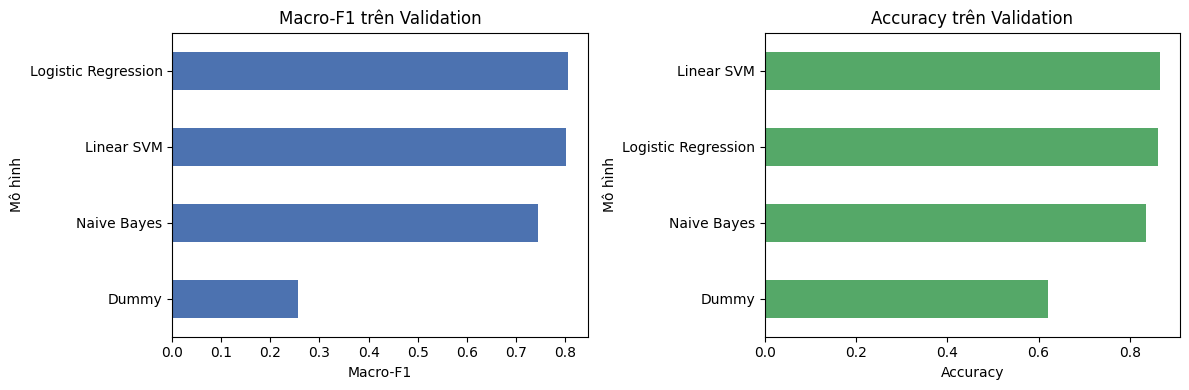

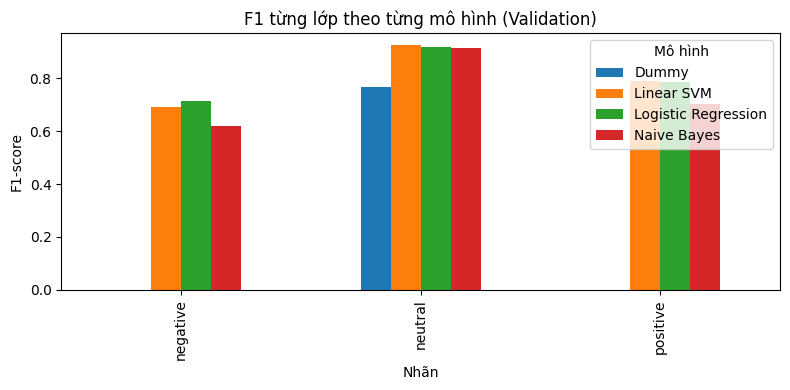

In [9]:
# ============================================================
# BƯỚC 3: Trực quan hóa so sánh 4 mô hình trên validation
# ============================================================
if not val_metrics_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    val_metrics_df.sort_values('Macro-F1').plot(
        x='Mô hình', y='Macro-F1', kind='barh', ax=axes[0], legend=False,
        color='#4C72B0', title='Macro-F1 trên Validation'
    )
    axes[0].set_xlabel('Macro-F1')

    val_metrics_df.sort_values('Accuracy').plot(
        x='Mô hình', y='Accuracy', kind='barh', ax=axes[1], legend=False,
        color='#55A868', title='Accuracy trên Validation'
    )
    axes[1].set_xlabel('Accuracy')

    plt.tight_layout()
    plt.savefig(FIGURES / 'baseline_validation_comparison.png', dpi=160)
    plt.show()

    # F1 từng lớp cho từng mô hình -> thấy rõ mô hình nào yếu ở lớp nào
    pivot_f1 = val_metrics_per_class_df.pivot(index='Nhãn', columns='Mô hình', values='F1').reindex(LABEL_ORDER)
    ax = pivot_f1.plot(kind='bar', figsize=(8, 4), title='F1 từng lớp theo từng mô hình (Validation)')
    ax.set_xlabel('Nhãn')
    ax.set_ylabel('F1-score')
    plt.tight_layout()
    plt.savefig(FIGURES / 'baseline_f1_per_class.png', dpi=160)
    plt.show()
else:
    print('Không có dữ liệu validation để vẽ biểu đồ.')

## 9. Đánh giá test cho baseline tốt nhất
Tập test chỉ được dùng **một lần duy nhất**, sau khi mô hình đã được chọn xong bằng validation. Ngoài classification report và confusion matrix theo số lượng như bản gốc, phần này bổ sung thêm **confusion matrix theo tỷ lệ % trên từng hàng** - giúp so sánh công bằng giữa các lớp có số lượng mẫu chênh lệch nhau.

===== Kết quả trên TEST cho mô hình tốt nhất (Logistic Regression) =====


,Mô hình,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1
0,Logistic Regression,0.8571,0.8487,0.7842,0.81,0.8545



===== Bảng chi tiết theo từng lớp trên TEST =====


,Mô hình,Nhãn,Precision,Recall,F1,Số mẫu
0,Logistic Regression,negative,0.8913,0.6508,0.7523,63
1,Logistic Regression,neutral,0.8879,0.9348,0.9107,322
2,Logistic Regression,positive,0.7669,0.7669,0.7669,133



===== Báo cáo phân loại đầy đủ (classification report) =====
              precision    recall  f1-score   support

    negative       0.89      0.65      0.75        63
     neutral       0.89      0.93      0.91       322
    positive       0.77      0.77      0.77       133

    accuracy                           0.86       518
   macro avg       0.85      0.78      0.81       518
weighted avg       0.86      0.86      0.85       518



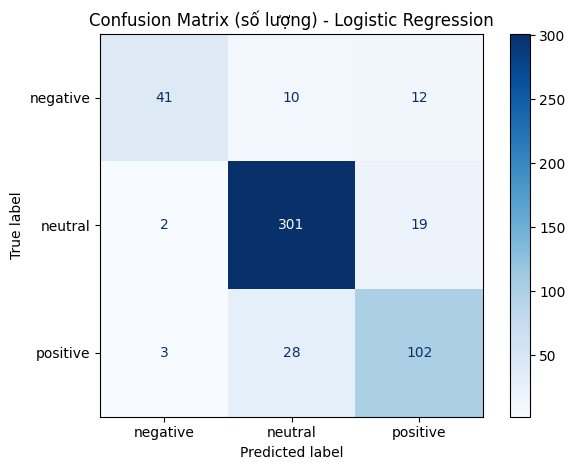

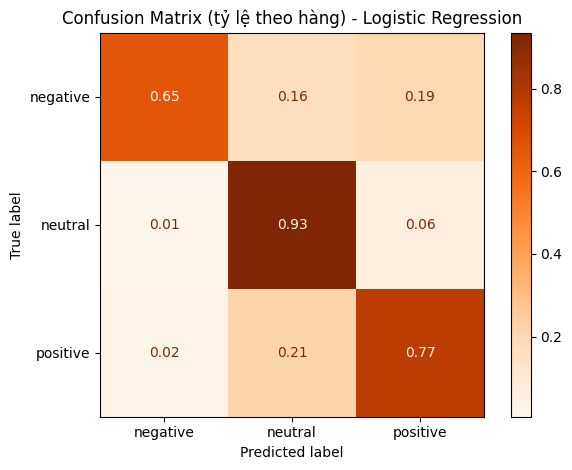


=> Recall thường thấp nhất ở lớp "negative" vì đây là lớp ít mẫu nhất trong tập test (63 câu).


In [10]:
# ============================================================
# Đánh giá mô hình tốt nhất trên tập TEST (chỉ chấm 1 lần duy nhất)
# ============================================================
test_metrics_df = pd.DataFrame()
test_metrics_per_class_df = pd.DataFrame()
best_model_name = None
best_model = None

if best_baseline_model is not None:
    test_pred = best_baseline_model.predict(test_df['sentence_clean'])

    test_metrics_df = pd.DataFrame([compute_metrics(test_df['label'], test_pred, best_baseline_name)])
    test_metrics_per_class_df = compute_metrics_per_class(test_df['label'], test_pred, best_baseline_name)

    print(f'===== Kết quả trên TEST cho mô hình tốt nhất ({best_baseline_name}) =====')
    display(test_metrics_df.round(4))

    print()
    print('===== Bảng chi tiết theo từng lớp trên TEST =====')
    display(test_metrics_per_class_df.round(4))

    print()
    print('===== Báo cáo phân loại đầy đủ (classification report) =====')
    print(classification_report(test_df['label'], test_pred, labels=LABEL_ORDER, zero_division=0))

    # --- Confusion matrix: số lượng tuyệt đối ---
    cm = confusion_matrix(test_df['label'], test_pred, labels=LABEL_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_ORDER)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix (số lượng) - {best_baseline_name}')
    plt.tight_layout()
    plt.savefig(FIGURES / 'best_model_confusion_matrix_counts.png', dpi=160)
    plt.show()

    # --- Confusion matrix: theo tỷ lệ % trên mỗi hàng ---
    # Giúp so sánh công bằng giữa các lớp có số lượng mẫu chênh lệch nhau
    # (vd. negative chỉ có 63 câu trong khi neutral có tới 322 câu)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    disp_norm = ConfusionMatrixDisplay(cm_normalized, display_labels=LABEL_ORDER)
    disp_norm.plot(cmap='Oranges', values_format='.2f')
    plt.title(f'Confusion Matrix (tỷ lệ theo hàng) - {best_baseline_name}')
    plt.tight_layout()
    plt.savefig(FIGURES / 'best_model_confusion_matrix_normalized.png', dpi=160)
    plt.show()

    best_model_name = best_baseline_name
    best_model = best_baseline_model
    STAGE_STATUS['test'] = 'done'

    n_negative = int((test_df['label'] == 'negative').sum())
    print()
    print(f'=> Recall thường thấp nhất ở lớp "negative" vì đây là lớp ít mẫu nhất trong tập test ({n_negative} câu).')
else:
    STAGE_STATUS['test'] = 'skipped_no_baseline'
    print('Chưa có mô hình baseline để đánh giá trên test.')

## 10. So sánh mô hình và phân tích lỗi

Phần này tổng hợp kết quả cuối cùng trên tập test, sau đó phân tích lỗi theo 4 hướng:
1. Các cặp nhầm lẫn phổ biến nhất (nhãn thật → nhãn đoán).
2. Tỷ lệ lỗi theo đặc trưng câu (có phủ định / có số / có % / có tiền tệ).
3. Tỷ lệ lỗi theo độ dài câu.
4. Ví dụ cụ thể minh họa cho từng kiểu nhầm lẫn phổ biến nhất.

===== Bảng kết quả cuối cùng trên tập TEST =====


,Mô hình,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1
0,Logistic Regression,0.8571,0.8487,0.7842,0.81,0.8545


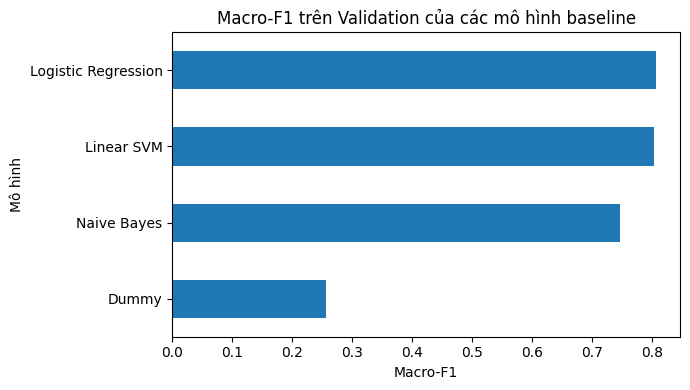


Tổng số câu trong tập test: 518
Số câu đoán sai: 74 (14.29%)

===== Các kiểu nhầm lẫn phổ biến nhất (nhãn thật -> nhãn đoán) =====


,Nhãn thật,Nhãn đoán,Số câu
0,positive,neutral,28
1,neutral,positive,19
2,negative,positive,12
3,negative,neutral,10
4,positive,negative,3
5,neutral,negative,2



===== Tỷ lệ lỗi theo đặc trưng câu =====


,Đặc trưng,Tỷ lệ lỗi khi CÓ đặc trưng,Tỷ lệ lỗi khi KHÔNG CÓ đặc trưng
0,Có từ phủ định,0.0500,0.1466
1,Có chữ số,0.1429,0.1429
2,Có ký hiệu phần trăm,0.1379,0.1435
3,Có ký hiệu tiền tệ,0.2500,0.1394



===== Tỷ lệ lỗi theo độ dài câu =====


...

,Câu gốc
15,Acquisitions have been made and businesses hav...
40,"The 50-50 joint venture , to be called Nokia S..."
42,"Fiskars , the World 's 1 Scissors Brand TM , ..."


-- Thật: neutral | Đoán: positive (19 câu) --


,Câu gốc
48,Aspo has also investigated the sales opportuni...
105,Karppinen expects the consolidation trend to c...
108,Mr K.R. Vasantha has been appointed Managing D...


-- Thật: negative | Đoán: positive (12 câu) --


,Câu gốc
65,"Copper , lead and nickel also dropped ... HBOS..."
217,The company said that sales in the three month...
274,26 October 2010 - Finnish environmental manage...


In [11]:
FEATURE_LABELS_VI = {
    'has_negation': 'Có từ phủ định',
    'has_number': 'Có chữ số',
    'has_percent': 'Có ký hiệu phần trăm',
    'has_currency': 'Có ký hiệu tiền tệ',
}

if not test_metrics_df.empty:
    final_metrics_df = test_metrics_df.copy()

    print('===== Bảng kết quả cuối cùng trên tập TEST =====')
    display(final_metrics_df.round(4))

    if not val_metrics_df.empty:
        ax = val_metrics_df.sort_values('Macro-F1').plot(
            x='Mô hình', y='Macro-F1', kind='barh', figsize=(7, 4), legend=False,
            title='Macro-F1 trên Validation của các mô hình baseline'
        )
        ax.set_xlabel('Macro-F1')
        plt.tight_layout()
        plt.savefig(FIGURES / 'model_macro_f1_comparison.png', dpi=160)
        plt.show()

    # ============================================================
    # PHÂN TÍCH LỖI CHI TIẾT
    # ============================================================
    if best_model is not None:
        pred = best_model.predict(test_df['sentence_clean'])
        analysis_df = test_df.assign(predicted_label=pred)
        analysis_df['is_correct'] = analysis_df['label'] == analysis_df['predicted_label']
        errors = analysis_df[~analysis_df['is_correct']].copy()

        print()
        print(f'Tổng số câu trong tập test: {len(analysis_df)}')
        print(f'Số câu đoán sai: {len(errors)} ({len(errors) / len(analysis_df):.2%})')

        # --- 1) Các cặp nhầm lẫn phổ biến nhất (nhãn thật -> nhãn đoán) ---
        error_pair_counts = (
            errors.groupby(['label', 'predicted_label']).size()
            .reset_index(name='Số câu')
            .rename(columns={'label': 'Nhãn thật', 'predicted_label': 'Nhãn đoán'})
            .sort_values('Số câu', ascending=False)
            .reset_index(drop=True)
        )
        print()
        print('===== Các kiểu nhầm lẫn phổ biến nhất (nhãn thật -> nhãn đoán) =====')
        display(error_pair_counts)

        # --- 2) Tỷ lệ lỗi theo đặc trưng câu ---
        feature_cols = ['has_negation', 'has_number', 'has_percent', 'has_currency']
        error_rate_by_feature = []
        for col in feature_cols:
            if col in analysis_df.columns:
                has_true = analysis_df[col].any()
                rate_true = (1 - analysis_df.loc[analysis_df[col], 'is_correct'].mean()) if has_true else float('nan')
                rate_false = 1 - analysis_df.loc[~analysis_df[col], 'is_correct'].mean()
                error_rate_by_feature.append({
                    'Đặc trưng': FEATURE_LABELS_VI.get(col, col),
                    'Tỷ lệ lỗi khi CÓ đặc trưng': rate_true,
                    'Tỷ lệ lỗi khi KHÔNG CÓ đặc trưng': rate_false,
                })
        error_rate_by_feature_df = pd.DataFrame(error_rate_by_feature)
        print()
        print('===== Tỷ lệ lỗi theo đặc trưng câu =====')
        display(error_rate_by_feature_df.round(4))

        # --- 3) Tỷ lệ lỗi theo độ dài câu ---
        analysis_df['length_bucket'] = pd.cut(
            analysis_df['word_count'], bins=[0, 10, 20, 30, 1000],
            labels=['≤10 từ', '11-20 từ', '21-30 từ', '>30 từ']
        )
        error_rate_by_length = (
            analysis_df.groupby('length_bucket', observed=True)['is_correct']
            .agg(**{'Số câu': 'count', 'Tỷ lệ đúng': 'mean'})
        )
        error_rate_by_length['Tỷ lệ lỗi'] = 1 - error_rate_by_length['Tỷ lệ đúng']
        error_rate_by_length.index.name = 'Độ dài câu'
        print()
        print('===== Tỷ lệ lỗi theo độ dài câu =====')
        display(error_rate_by_length.round(4))

        # --- 4) Ví dụ cụ thể cho từng kiểu nhầm lẫn phổ biến nhất ---
        print()
        print('===== Ví dụ cụ thể cho 3 kiểu nhầm lẫn phổ biến nhất =====')
        for _, row in error_pair_counts.head(3).iterrows():
            true_l, pred_l = row['Nhãn thật'], row['Nhãn đoán']
            subset = errors[(errors['label'] == true_l) & (errors['predicted_label'] == pred_l)]
            print(f'-- Thật: {true_l} | Đoán: {pred_l} ({len(subset)} câu) --')
            display(subset[['sentence_original']].rename(columns={'sentence_original': 'Câu gốc'}).head(3))
    else:
        print('Chưa có mô hình tốt nhất để phân tích lỗi.')
else:
    final_metrics_df = pd.DataFrame()
    print('Chưa có kết quả mô hình để so sánh. Hãy chạy notebook trong môi trường có Internet để tải dữ liệu.')

## 11. Ứng dụng trên báo cáo PDF

Phần này minh họa cách áp dụng mô hình tốt nhất để dự đoán cảm xúc các câu trích xuất từ một báo cáo thường niên. Kết quả chỉ phản ánh sắc thái ngôn ngữ, không phải khuyến nghị đầu tư.

In [12]:
def extract_text_from_pdf(pdf_path):
    text = ''
    try:
        import fitz
        doc = fitz.open(str(pdf_path))
        for page in doc:
            text += page.get_text('text') + '\n'
        doc.close()
    except Exception:
        import pdfplumber
        with pdfplumber.open(str(pdf_path)) as pdf:
            for page in pdf.pages:
                text += (page.extract_text() or '') + '\n'
    return text

def split_sentences(text, min_words=6, max_words=80):
    candidates = re.split(r'(?<=[.!?])\s+(?=[A-Z0-9])', normalize_text(text))
    return [s.strip() for s in candidates if min_words <= len(s.split()) <= max_words]

report_df = pd.DataFrame()
pdf_path = None
if RUN_REPORT_INFERENCE:
    if REPORT_PDF_PATH:
        pdf_path = Path(REPORT_PDF_PATH)
    elif IN_COLAB:
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            pdf_path = Path(next(iter(uploaded.keys())))
    if pdf_path and pdf_path.exists() and best_model is not None:
        text = extract_text_from_pdf(pdf_path)
        sentences = split_sentences(text)
        report_df = pd.DataFrame({'sentence': sentences})
        report_df['sentence_clean'] = report_df['sentence'].map(clean_for_tfidf)
        report_df['predicted_label'] = best_model.predict(report_df['sentence_clean'])
        display(report_df.head(10))
        summary = report_df['predicted_label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
        display(pd.DataFrame({'count': summary, 'ratio': (summary/summary.sum()).round(4)}))
        ax = summary.plot(kind='bar', title='Tỷ lệ cảm xúc trong báo cáo PDF')
        ax.set_xlabel('Nhãn')
        ax.set_ylabel('Số câu')
        plt.tight_layout()
        plt.savefig(FIGURES/'pdf_sentiment_distribution.png', dpi=160)
        plt.show()
    elif best_model is None:
        print('Chưa có mô hình để dự đoán PDF.')
    else:
        print('Chưa có file PDF hợp lệ.')
else:
    print('RUN_REPORT_INFERENCE=False nên bỏ qua phần PDF. Khi cần chạy, đặt True và cung cấp REPORT_PDF_PATH hoặc tải PDF lên Colab.')

Chưa có file PDF hợp lệ.


## 12. Tổng kết

Notebook này cung cấp pipeline hoàn chỉnh cho bài cuối học phần NLP: thu thập dữ liệu, tiền xử lý, EDA, huấn luyện và tinh chỉnh 4 mô hình baseline, đánh giá trên test, phân tích lỗi chi tiết và ứng dụng lên báo cáo PDF thật. Khi chạy trên môi trường có Internet, nhóm cần cập nhật báo cáo và slide bằng đúng số liệu cuối cùng trong notebook.

In [13]:
print('===== Trạng thái các giai đoạn =====')
for k, v in STAGE_STATUS.items():
    print(f'  - {k}: {v}')

print()
if not final_metrics_df.empty:
    print('Mô hình tốt nhất hiện tại:', best_model_name)
    display(final_metrics_df.round(4))
else:
    print('Chưa có metrics thực nghiệm trong môi trường hiện tại.')

print()
print('Các hình đã lưu trong thư mục:', FIGURES.resolve())

===== Trạng thái các giai đoạn =====
  - data: done
  - data_source: ZIP chính thức: data/FinancialPhraseBank-v1.0.zip
  - baseline: done
  - test: done

Mô hình tốt nhất hiện tại: Logistic Regression


,Mô hình,Accuracy,Macro Precision,Macro Recall,Macro-F1,Weighted-F1
0,Logistic Regression,0.8571,0.8487,0.7842,0.81,0.8545



Các hình đã lưu trong thư mục: /content/figures_from_notebook
